In [18]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

import torch
from torch.utils.data import Dataset
import transformers
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
    TrainingArguments, Trainer, TrainerCallback,
)
from peft import LoraConfig, get_peft_model
from trl import SFTConfig, SFTTrainer

from meft import MeftConfig, MeftTrainer
from transformers import LlamaForCausalLM, LlamaTokenizer
from datasets import load_dataset
from transformers import BitsAndBytesConfig
from trl import SFTTrainer,SFTConfig

import logging
import socket
from datetime import datetime, timedelta

from torch.autograd.profiler import record_function
from utils.prompter import Prompter


In [19]:
base_model="meta-llama/Llama-2-7b-hf"
data_path="yahma/alpaca-cleaned" # 'chiayewken/flan-v2' 'Salesforce/wikitext'-'wikitext-2-raw-v1'
device_map="auto"
num_epoch=1
lr=3e-5
compress_rank=0.0625
micro_batch_size=16
batch_size=128
gradient_accumulation_steps=batch_size // micro_batch_size
lora_weights_output_dir="memory_test"
cutoff_len=256
train_on_inputs=True
using_meft=True
file_prefix = f"norm_ckpt"
patch_locations=2
if patch_locations == 1:
    meft_patch_locations=("ckpt_layer",)
elif patch_locations == 2:
    meft_patch_locations=("norm", "ckpt_attn", "ckpt_mlp",)
else:
    raise ValueError("patch_locations must be 1 or 2")

In [20]:

model = LlamaForCausalLM.from_pretrained(
    base_model,
    # quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map=device_map,
)

tokenizer = LlamaTokenizer.from_pretrained(base_model)

tokenizer.pad_token_id = (
    0  # unk. we want this to be different from the eos token
)
tokenizer.padding_side = "left"  # Allow batched inference

INFO:2025-09-18 20:08:14 We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [21]:
config = LoraConfig(
    r=64,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 33,554,432 || all params: 6,771,970,048 || trainable%: 0.4955


In [22]:
def tokenize(prompt, add_eos_token=True):
    # there's probably a way to do this with the tokenizer settings
    # but again, gotta move fast
    result = tokenizer(
        prompt,
        truncation=True,
        max_length=cutoff_len,
        padding=False,
        return_tensors=None,
    )
    if (
        result["input_ids"][-1] != tokenizer.eos_token_id
        and len(result["input_ids"]) < cutoff_len
        and add_eos_token
    ):
        result["input_ids"].append(tokenizer.eos_token_id)
        result["attention_mask"].append(1)

    result["labels"] = result["input_ids"].copy()

    return result

def generate_and_tokenize_prompt(data_point):
    full_prompt = prompter.generate_prompt(
        data_point["instruction"],
        data_point["input"],
        data_point["output"],
    )
    tokenized_full_prompt = tokenize(full_prompt)
    if not train_on_inputs:
        user_prompt = prompter.generate_prompt(
            data_point["instruction"], data_point["input"]
        )
        tokenized_user_prompt = tokenize(
            user_prompt, add_eos_token=add_eos_token
        )
        user_prompt_len = len(tokenized_user_prompt["input_ids"])

        if add_eos_token:
            user_prompt_len -= 1

        tokenized_full_prompt["labels"] = [
            -100
        ] * user_prompt_len + tokenized_full_prompt["labels"][
            user_prompt_len:
        ]  # could be sped up, probably
    return tokenized_full_prompt

In [23]:
data=load_dataset(data_path)
prompter = Prompter("alpaca")
val_set_size=2000

if val_set_size > 0:
    train_val = data["train"].train_test_split(
        test_size=val_set_size, shuffle=True, seed=42
    )
    train_data = (
        train_val["train"].shuffle().map(generate_and_tokenize_prompt)
    )
    val_data = (
        train_val["test"].shuffle().map(generate_and_tokenize_prompt)
    )
else:
    train_data = data["train"].shuffle().map(generate_and_tokenize_prompt)
    val_data = None
    
print("slicing train_data to 1000 for testing")
train_data = train_data.select(range(1000))
print("after slicing, train_data:", train_data)

Map:   0%|          | 0/49760 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

slicing train_data to 1000 for testing
after slicing, train_data: Dataset({
    features: ['instruction', 'input', 'output', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 1000
})


In [24]:
if using_meft:
    trainer = MeftTrainer[SFTTrainer](
            model=model,
            train_dataset=train_data,
            eval_dataset=val_data,
            args=SFTConfig(
                per_device_train_batch_size=micro_batch_size,
                gradient_accumulation_steps=gradient_accumulation_steps,
                warmup_steps=100,
                num_train_epochs=1,
                learning_rate=3e-5,
                weight_decay=1e-2,
                lr_scheduler_type="cosine",
                bf16=True,
                bf16_full_eval=True,
                use_liger_kernel=True,
                logging_steps=10,
                optim="adamw_torch",
                eval_strategy="steps" if val_set_size > 0 else "no",
                save_strategy="steps",
                eval_steps=100 if val_set_size > 0 else None,
                save_steps=200,
                # metric_for_best_model="eval_loss",
                # greater_is_better=False,
                output_dir=lora_weights_output_dir,
                # save_total_limit=3,
                # load_best_model_at_end=True if val_set_size > 0 else False,
            ),
            # data_collator=transformers.DataCollatorForSeq2Seq(
            #     tokenizer, pad_to_multiple_of=8, return_tensors="pt", padding=True
            # ),
            # compute_metrics=compute_metrics,
            meft_config=MeftConfig(
                patch_locations=("ckpt_layer",), # ("norm", "ckpt_attn", "ckpt_mlp",), # patch_locations=("ckpt_layer",),   
                # compress_kwargs={"rank": compress_rank},
            ),
    )
else:
    trainer = transformers.Trainer(
        model=model,
        train_dataset=train_data,
        eval_dataset=val_data,
        args=transformers.TrainingArguments(
            per_device_train_batch_size=micro_batch_size,
            gradient_accumulation_steps=gradient_accumulation_steps,
            warmup_steps=100,
            num_train_epochs=1,
            learning_rate=3e-5,
            bf16=True,
            bf16_full_eval=True,
            use_liger_kernel=True,
            logging_steps=10,
            optim="adamw_torch",
            eval_strategy="steps" if val_set_size > 0 else "no",
            save_strategy="steps",
            eval_steps=100 if val_set_size > 0 else None,
            save_steps=200,
            # metric_for_best_model="eval_loss",
            # greater_is_better=False,
            # output_dir=lora_weights_output_dir,
            # save_total_limit=3,
            # load_best_model_at_end=True if val_set_size > 0 else False,
            # ddp_find_unused_parameters=False if ddp else None,
            # group_by_length=group_by_length,
            # report_to="wandb" if use_wandb else None,
            # run_name=wandb_run_name if use_wandb else None,
        ),
        data_collator=transformers.DataCollatorForSeq2Seq(
            tokenizer, pad_to_multiple_of=8, return_tensors="pt", padding=True
        ),
    )


Truncating train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

INFO:2025-09-18 20:09:10 Applying Liger kernels to model instance with model type: llama with kwargs: {}


Applying patch to llama model in: ('ckpt_layer',)


In [25]:
class ProfCallback(TrainerCallback):
    def __init__(self, prof):
        self.prof = prof

    def on_step_end(self, args, state, control, **kwargs):
        self.prof.step()

Setting `use_cache=False` during training.


Step,Training Loss,Validation Loss


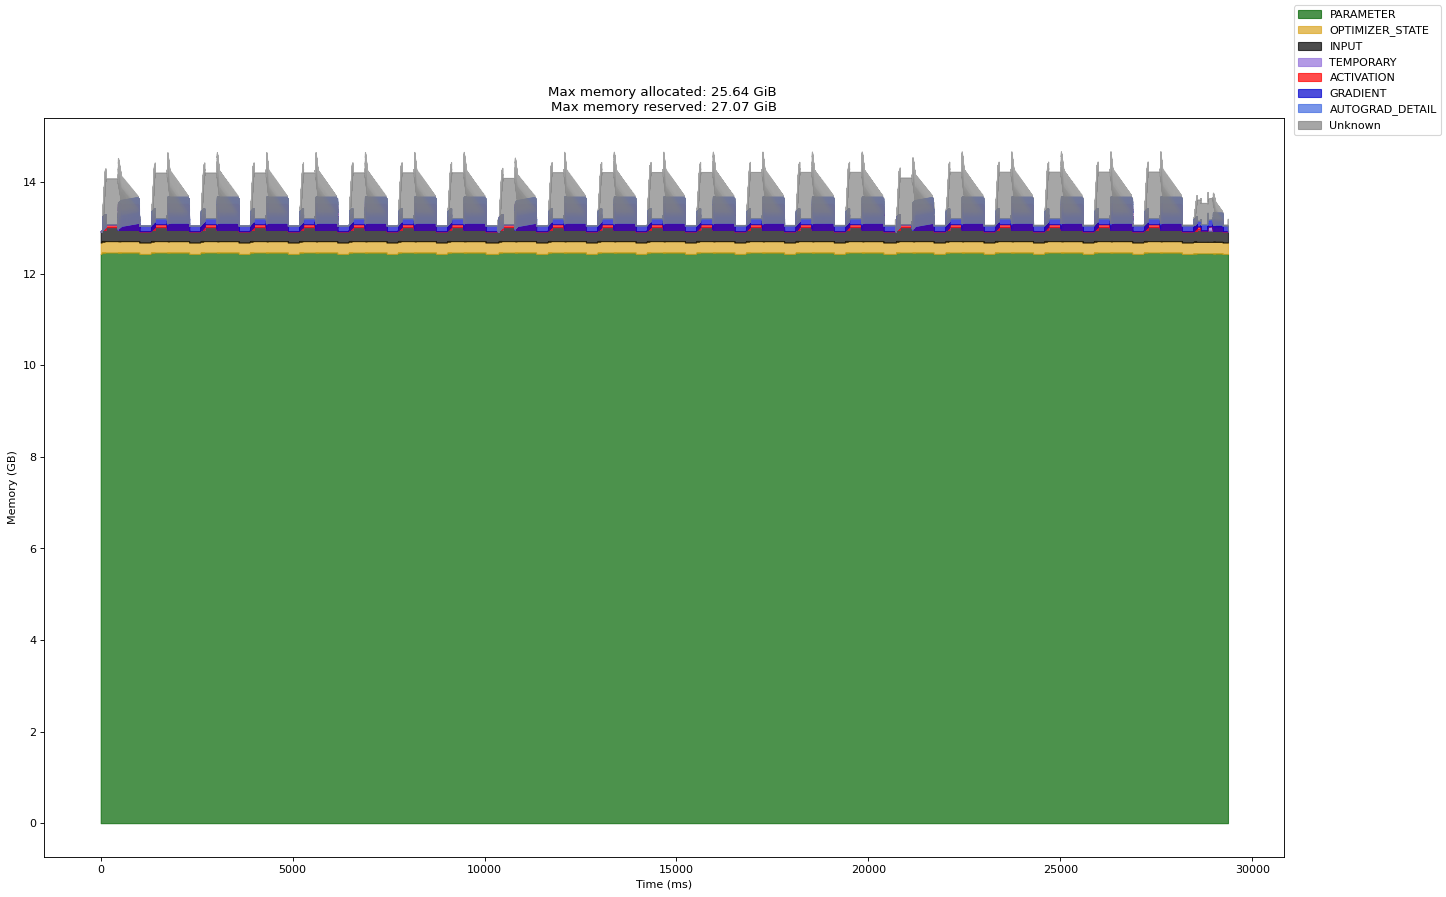

In [26]:
logging.basicConfig(
   format="%(levelname)s:%(asctime)s %(message)s",
   level=logging.INFO,
   datefmt="%Y-%m-%d %H:%M:%S",
)
logger: logging.Logger = logging.getLogger(__name__)
logger.setLevel(level=logging.INFO)

TIME_FORMAT_STR: str = "%b_%d_%H_%M_%S"

# Prefix for file names.
host_name = socket.gethostname()
timestamp = datetime.now().strftime(TIME_FORMAT_STR)


def trace_handler(prof: torch.profiler.profile):

   # Construct the trace file.
   # prof.export_chrome_trace(f"{file_prefix}.json.gz")

   # Construct the memory timeline file.
   prof.export_memory_timeline(f"./profiler/{file_prefix}.html", device="cuda:0")
   prof.export_memory_timeline(f"./profiler/{file_prefix}.json", device="cuda:0")


with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA],
    schedule=torch.profiler.schedule(skip_first=3, wait=1, warmup=1, active=3, repeat=1),
    profile_memory=True,
    with_stack=True,
    record_shapes=True,
    on_trace_ready=trace_handler,
) as prof:
    trainer.add_callback(ProfCallback(prof=prof))
    trainer.train()

In [27]:
import json
import numpy as np
import matplotlib.pyplot as plt
from torch.profiler._memory_profiler import _CATEGORY_TO_COLORS, _CATEGORY_TO_INDEX

with open(f"./profiler/{file_prefix}.json", "r") as f:
# with open(f"./profiler/shijx-3090_Jul_13_04_23_54.json", "r") as f:
    mt = json.load(f)
# with open(f"./profiler/layer_0.5.json", "r") as f:
#      mt = json.load(f)
times, sizes = np.array(mt[0]), np.array(mt[1])
t_min = min(times)
times -= t_min

Category.PARAMETER 12.465434551239014
Category.OPTIMIZER_STATE 0.25
Category.INPUT 0.4323742389678955
Category.TEMPORARY 0.56787109375
Category.ACTIVATION 0.31465911865234375
Category.GRADIENT 0.1875
Category.AUTOGRAD_DETAIL 0.0625
None 1.118873119354248
14.677712678909302


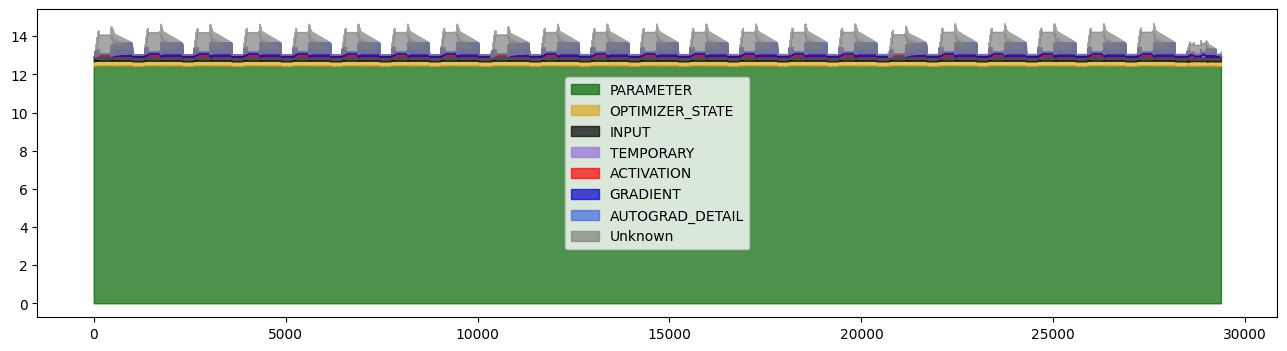

In [28]:
stacked = np.cumsum(sizes, axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for category, color in _CATEGORY_TO_COLORS.items():
    i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i in _CATEGORY_TO_COLORS])

for category, color in _CATEGORY_TO_COLORS.items():
    i = _CATEGORY_TO_INDEX[category]
    print(category, (stacked[:, i+1] - stacked[:, i]).max())

print(stacked[:, -1].max())

12.465434551239014
12.432136535644531


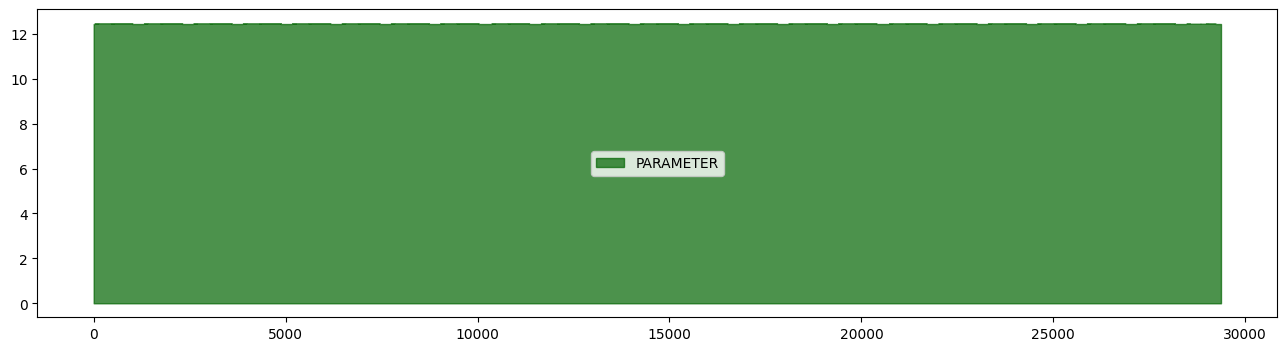

In [29]:
k = (0,)
items = [list(_CATEGORY_TO_COLORS.items())[i] for i in k]
stacked = np.cumsum(sizes[:, (0, *(i+1 for i in k))], axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for i, (category, color) in enumerate(items):
    # i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i, _ in items])

print(stacked[:, -1].max())
print(stacked[:, -1].min())

0.25
0.25


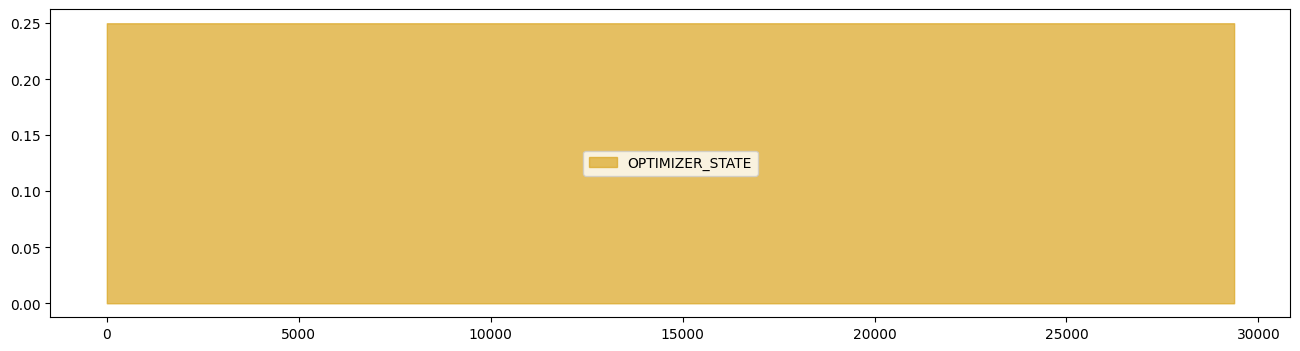

In [30]:
k = (1,)
items = [list(_CATEGORY_TO_COLORS.items())[i] for i in k]
stacked = np.cumsum(sizes[:, (0, *(i+1 for i in k))], axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for i, (category, color) in enumerate(items):
    # i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i, _ in items])

print(stacked[:, -1].max())
print(stacked[:, -1].min())

0.4323742389678955
0.2441408634185791


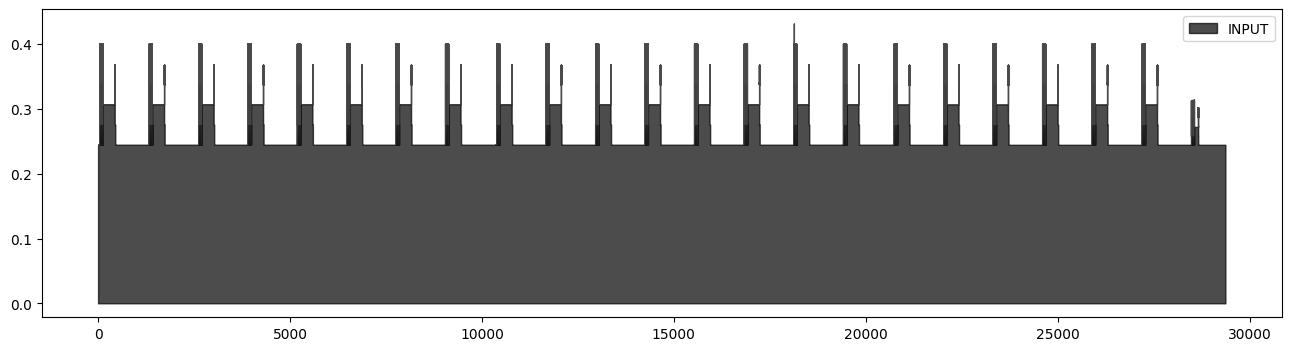

In [31]:
k = (2,)
items = [list(_CATEGORY_TO_COLORS.items())[i] for i in k]
stacked = np.cumsum(sizes[:, (0, *(i+1 for i in k))], axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for i, (category, color) in enumerate(items):
    # i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i, _ in items])

print(stacked[:, -1].max())
print(stacked[:, -1].min())

0.31465911865234375


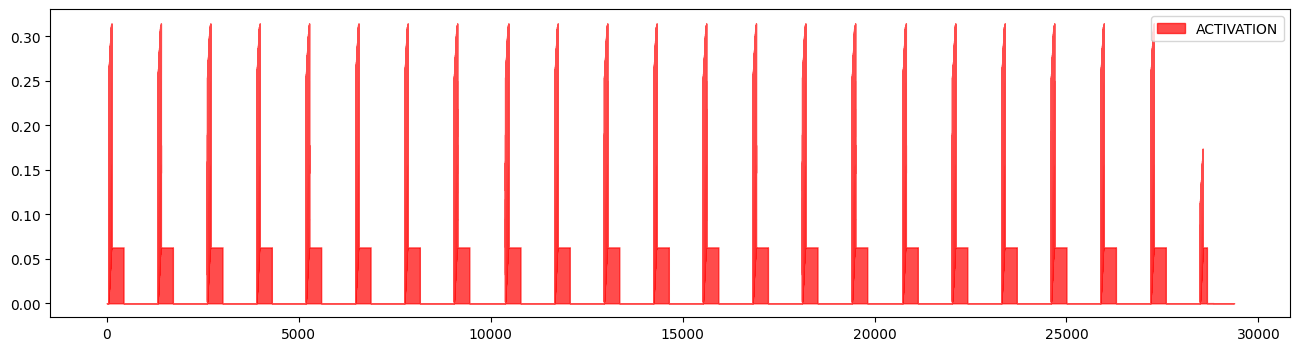

In [32]:
k = (4,)
items = [list(_CATEGORY_TO_COLORS.items())[i] for i in k]
stacked = np.cumsum(sizes[:, (0, *(i+1 for i in k))], axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for i, (category, color) in enumerate(items):
    # i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i, _ in items])

print(stacked[:, -1].max())

1.5612101554870605


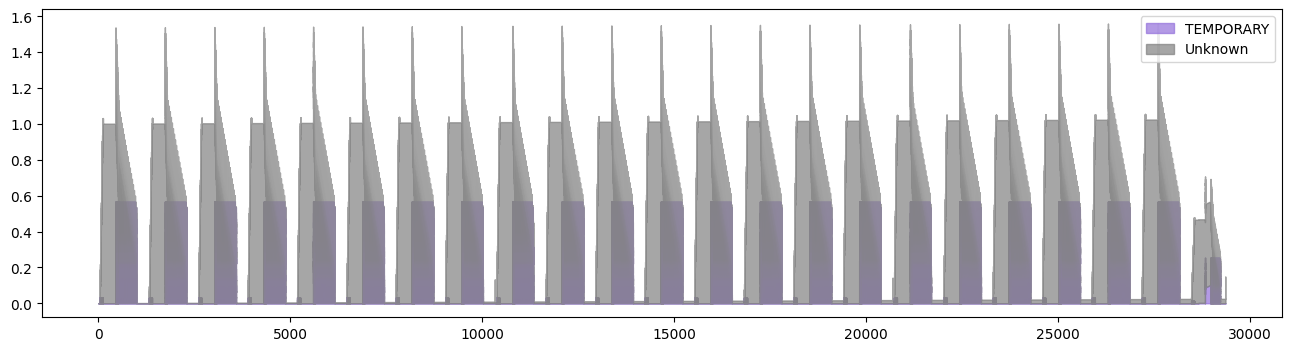

In [33]:
k = (3,7,)
items = [list(_CATEGORY_TO_COLORS.items())[i] for i in k]
stacked = np.cumsum(sizes[:, (0, *(i+1 for i in k))], axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for i, (category, color) in enumerate(items):
    # i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i, _ in items])

print(stacked[:, -1].max())

0.1876220703125


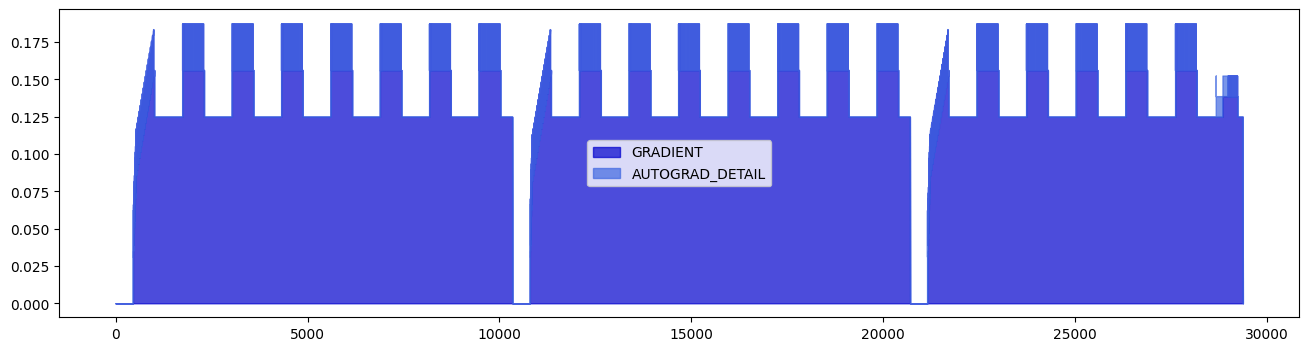

: 

In [ ]:
k = (5,6)
items = [list(_CATEGORY_TO_COLORS.items())[i] for i in k]
stacked = np.cumsum(sizes[:, (0, *(i+1 for i in k))], axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for i, (category, color) in enumerate(items):
    # i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i, _ in items])

print(stacked[:, -1].max())